In [ ]:
!pip install ucimlrepo -q

# Additional Classification Models

To compare different classifier families, two additional models were implemented: Decision Tree and K-Nearest Neighbors (KNN). Decision Tree represents a tree-based approach that can capture nonlinear relationships, while KNN is an instance-based classifier that predicts classes based on similarity between samples.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

dt_cv_scores = cross_val_score(
    decision_tree,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Decision Tree Cross-validation scores:", dt_cv_scores)
print("Decision Tree Mean CV Accuracy:", dt_cv_scores.mean())

In [ ]:
decision_tree.fit(X_train, y_train)

dt_pred = decision_tree.predict(X_test)

print("Decision Tree trained successfully.")

In [ ]:
knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_cv_scores = cross_val_score(
    knn_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("KNN Cross-validation scores:", knn_cv_scores)
print("KNN Mean CV Accuracy:", knn_cv_scores.mean())

In [ ]:
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN trained successfully.")

## Model Selection Summary

Three classifiers from different families were used:

- **Logistic Regression:** A linear classifier used as the baseline model.
- **Decision Tree:** A tree-based classifier capable of learning nonlinear decision rules.
- **K-Nearest Neighbors (KNN):** An instance-based classifier that predicts a sample based on its nearest training examples.

Five-fold cross-validation was applied to all three models using only the training data to provide a fair comparison and reduce dependence on a single split.

# Task 6: Performance Evaluation and Comparison

The three classifiers were evaluated on the same test set using Accuracy, F1-score, Confusion Matrix, and ROC-AUC. These metrics provide a fair comparison of the models' classification performance.

In [ ]:
# Logistic Regression predictions already exist as y_pred
lr_pred = y_pred

# Accuracy
lr_accuracy = accuracy_score(y_test, lr_pred)
dt_accuracy = accuracy_score(y_test, dt_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)

# F1-score for poisonous class
lr_f1 = f1_score(y_test, lr_pred, pos_label='p')
dt_f1 = f1_score(y_test, dt_pred, pos_label='p')
knn_f1 = f1_score(y_test, knn_pred, pos_label='p')

print("Logistic Regression Accuracy:", lr_accuracy)
print("Logistic Regression F1:", lr_f1)

print("\nDecision Tree Accuracy:", dt_accuracy)
print("Decision Tree F1:", dt_f1)

print("\nKNN Accuracy:", knn_accuracy)
print("KNN F1:", knn_f1)

In [ ]:
dt_cm = confusion_matrix(
    y_test,
    dt_pred,
    labels=['e', 'p']
)

display = ConfusionMatrixDisplay(
    confusion_matrix=dt_cm,
    display_labels=['Edible', 'Poisonous']
)

display.plot(cmap='Greens')
plt.title("Confusion Matrix – Decision Tree")
plt.grid(False)
plt.show()

In [ ]:
knn_cm = confusion_matrix(
    y_test,
    knn_pred,
    labels=['e', 'p']
)

display = ConfusionMatrixDisplay(
    confusion_matrix=knn_cm,
    display_labels=['Edible', 'Poisonous']
)

display.plot(cmap='Greens')
plt.title("Confusion Matrix – KNN")
plt.grid(False)
plt.show()

In [ ]:
# Decision Tree probabilities
dt_poisonous_index = list(decision_tree.classes_).index('p')
dt_probability = decision_tree.predict_proba(X_test)[:, dt_poisonous_index]

dt_auc = roc_auc_score(y_test_binary, dt_probability)


# KNN probabilities
knn_poisonous_index = list(knn_model.classes_).index('p')
knn_probability = knn_model.predict_proba(X_test)[:, knn_poisonous_index]

knn_auc = roc_auc_score(y_test_binary, knn_probability)


print("Logistic Regression ROC-AUC:", auc_score)
print("Decision Tree ROC-AUC:", dt_auc)
print("KNN ROC-AUC:", knn_auc)

In [ ]:
# Logistic Regression ROC already exists
lr_fpr, lr_tpr, _ = roc_curve(y_test_binary, y_probability)

# Decision Tree ROC
dt_fpr, dt_tpr, _ = roc_curve(y_test_binary, dt_probability)

# KNN ROC
knn_fpr, knn_tpr, _ = roc_curve(y_test_binary, knn_probability)

plt.figure(figsize=(7, 5))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f'Logistic Regression (AUC = {auc_score:.3f})'
)

plt.plot(
    dt_fpr,
    dt_tpr,
    label=f'Decision Tree (AUC = {dt_auc:.3f})'
)

plt.plot(
    knn_fpr,
    knn_tpr,
    label=f'KNN (AUC = {knn_auc:.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'KNN'
    ],

    'CV Accuracy': [
        cv_scores.mean(),
        dt_cv_scores.mean(),
        knn_cv_scores.mean()
    ],

    'Test Accuracy': [
        lr_accuracy,
        dt_accuracy,
        knn_accuracy
    ],

    'F1 Score': [
        lr_f1,
        dt_f1,
        knn_f1
    ],

    'ROC-AUC': [
        auc_score,
        dt_auc,
        knn_auc
    ]
})

results

# Task 7: Error Analysis

Error analysis was performed to investigate the mistakes made by the classifiers and identify possible patterns among misclassified samples.

In [ ]:
# Find samples incorrectly classified by Logistic Regression
error_mask = y_test != lr_pred

X_errors = X_test[error_mask].copy()
y_errors = y_test[error_mask]
pred_errors = lr_pred[error_mask]

print("Logistic Regression misclassified samples:", error_mask.sum())
print("Decision Tree misclassified samples:", (y_test != dt_pred).sum())
print("KNN misclassified samples:", (y_test != knn_pred).sum())

In [ ]:
error_analysis = pd.DataFrame({
    'Actual': y_errors.values,
    'Predicted': pred_errors
})

error_analysis

In [ ]:
error_counts = error_analysis.value_counts().reset_index(name='Count')

error_counts

In [ ]:
X_errors_display = X_errors.copy()

X_errors_display['Actual'] = y_errors.values
X_errors_display['Predicted'] = pred_errors

X_errors_display

In [ ]:
print("Total test samples:", len(y_test))
print("Logistic Regression errors:", (y_test != lr_pred).sum())
print("Decision Tree errors:", (y_test != dt_pred).sum())
print("KNN errors:", (y_test != knn_pred).sum())

In [ ]:
import pandas as pd
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split

In [ ]:
mushroom = fetch_ucirepo(id=73)

X = mushroom.data.features.copy()
y = mushroom.data.targets.squeeze().copy()

print("Dataset shape:", X.shape)
X.head()

Dataset shape: (8124, 22)


,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,x,s,n,t,p,f,c,n,k,e,...,s,w,w,p,w,o,p,k,s,u
1,x,s,y,t,a,f,c,b,k,e,...,s,w,w,p,w,o,p,n,n,g
2,b,s,w,t,l,f,c,b,n,e,...,s,w,w,p,w,o,p,n,n,m
3,x,y,w,t,p,f,c,n,n,e,...,s,w,w,p,w,o,p,k,s,u
4,x,s,g,f,n,f,w,b,k,t,...,s,w,w,p,w,o,e,n,a,g


## Data Understanding and Initial Inspection

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 22 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cap-shape                 8124 non-null   object
 1   cap-surface               8124 non-null   object
 2   cap-color                 8124 non-null   object
 3   bruises                   8124 non-null   object
 4   odor                      8124 non-null   object
 5   gill-attachment           8124 non-null   object
 6   gill-spacing              8124 non-null   object
 7   gill-size                 8124 non-null   object
 8   gill-color                8124 non-null   object
 9   stalk-shape               8124 non-null   object
 10  stalk-root                5644 non-null   object
 11  stalk-surface-above-ring  8124 non-null   object
 12  stalk-surface-below-ring  8124 non-null   object
 13  stalk-color-above-ring    8124 non-null   object
 14  stalk-color-below-ring  

In [ ]:
print("Missing values in each feature:")
print(X.isnull().sum())

Missing values in each feature:
cap-shape                      0
cap-surface                    0
cap-color                      0
bruises                        0
odor                           0
gill-attachment                0
gill-spacing                   0
gill-size                      0
gill-color                     0
stalk-shape                    0
stalk-root                  2480
stalk-surface-above-ring       0
stalk-surface-below-ring       0
stalk-color-above-ring         0
stalk-color-below-ring         0
veil-type                      0
veil-color                     0
ring-number                    0
ring-type                      0
spore-print-color              0
population                     0
habitat                        0
dtype: int64


In [ ]:
print("Number of duplicated rows:", X.duplicated().sum())

Number of duplicated rows: 0


In [ ]:
print("Class counts:")
print(y.value_counts())

print("\nClass percentages:")
print(y.value_counts(normalize=True) * 100)

Class counts:
poisonous
e    4208
p    3916
Name: count, dtype: int64

Class percentages:
poisonous
e    51.797144
p    48.202856
Name: proportion, dtype: float64


### Initial Inspection Findings

The dataset contains 8,124 samples and 22 categorical features. No duplicated rows were found. The `stalk-root` feature contains 2,480 missing values, while the remaining features have no missing values. The target distribution is approximately balanced, with 51.8% edible and 48.2% poisonous samples.

## Feature Reduction

In [ ]:
features_to_drop = ['odor', 'spore-print-color']

X = X.drop(columns=features_to_drop)

print("Dropped features:", features_to_drop)
print("Remaining number of features:", X.shape[1])

Dropped features: ['odor', 'spore-print-color']
Remaining number of features: 20


The `odor` and `spore-print-color` features were removed because they are strongly associated with mushroom edibility. Keeping these highly predictive features could make the classification task too easy. Removing them creates a more meaningful classification problem and satisfies the required feature-reduction condition.

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 6499
Testing samples: 1625


In [ ]:
most_common_root = X_train['stalk-root'].mode()[0]

X_train['stalk-root'] = X_train['stalk-root'].fillna(most_common_root)
X_test['stalk-root'] = X_test['stalk-root'].fillna(most_common_root)

print("Training missing values:", X_train.isnull().sum().sum())
print("Testing missing values:", X_test.isnull().sum().sum())

Training missing values: 0
Testing missing values: 0


## Categorical Feature Encoding

All input features are categorical. One-Hot Encoding was applied to convert each category into numerical binary columns that can be used by machine learning classifiers.

In [ ]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [ ]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("Training shape after encoding:", X_train.shape)
print("Testing shape after encoding:", X_test.shape)

Training shape after encoding: (6499, 98)
Testing shape after encoding: (1625, 98)


In [ ]:
print("Remaining missing values:", X_train.isnull().sum().sum())
print("Training data type:", X_train.dtypes.unique())
print("Target classes:", y_train.unique())

X_train.head()

Remaining missing values: 0
Training data type: [dtype('bool')]
Target classes: ['p' 'e']


,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
5249,False,False,True,False,False,False,False,False,False,True,...,False,False,True,False,True,False,False,False,False,False
5781,False,False,False,False,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,True
7586,True,False,False,False,False,False,False,False,True,False,...,True,False,False,False,True,False,False,False,False,False
6181,False,False,True,False,False,False,False,False,True,False,...,False,True,False,True,False,False,False,False,False,False
7338,False,False,False,True,False,False,False,False,False,True,...,False,True,False,False,False,False,False,True,False,False


## Preprocessing Summary

The dataset was divided into 80% training data and 20% testing data using stratified sampling to preserve the original class distribution. Missing values in `stalk-root` were replaced using the most frequent value calculated from the training data. The categorical features were converted into numerical form using One-Hot Encoding. The training and testing columns were then aligned to ensure they had the same structure. The resulting data is ready for model training.

# Exploratory Data Analysis

This section explores the target distribution and the relationships between selected mushroom features and edibility. Four meaningful visualizations are presented with clear captions and interpretations.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

## 1. Distribution of Edible and Poisonous Mushrooms

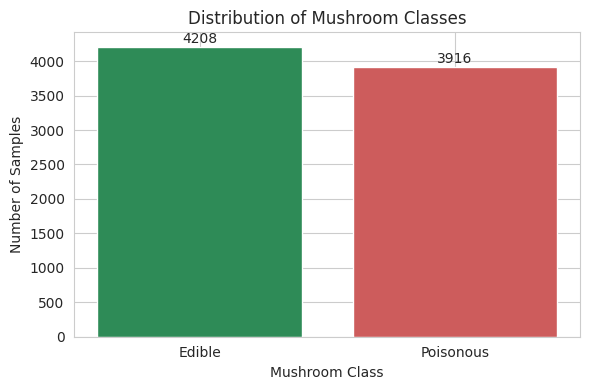

In [ ]:
class_counts = y.value_counts()
class_counts.index = ['Edible' if value == 'e' else 'Poisonous'
                      for value in class_counts.index]

plt.figure(figsize=(6, 4))
plt.bar(
    class_counts.index,
    class_counts.values,
    color=['seagreen', 'indianred']
)

plt.title("Distribution of Mushroom Classes")
plt.xlabel("Mushroom Class")
plt.ylabel("Number of Samples")

for i, value in enumerate(class_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.tight_layout()
plt.show()

**Figure 1: Distribution of edible and poisonous mushrooms.**

The dataset contains 4,208 edible mushrooms and 3,916 poisonous mushrooms. The two classes have similar sample counts, indicating that the dataset is approximately balanced. Therefore, no class-balancing method was required.

## 2. Gill Size and Mushroom Edibility

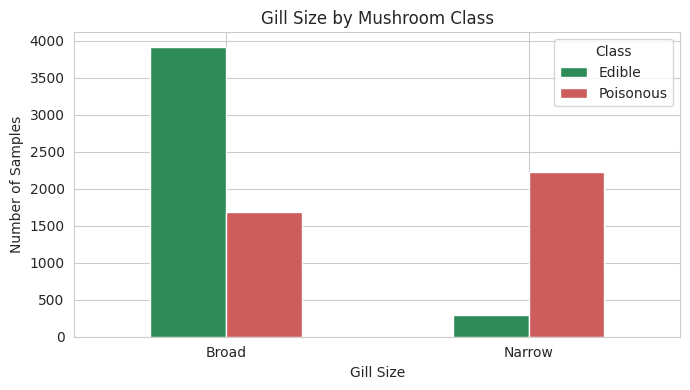

In [ ]:
gill_size_table = pd.crosstab(X['gill-size'], y)
gill_size_table.rename(
    index={'b': 'Broad', 'n': 'Narrow'},
    inplace=True
)
gill_size_table.columns = ['Edible', 'Poisonous']

gill_size_table.plot(
    kind='bar',
    figsize=(7, 4),
    color=['seagreen', 'indianred']
)

plt.title("Gill Size by Mushroom Class")
plt.xlabel("Gill Size")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

**Figure 2: Relationship between gill size and mushroom edibility.**

Broad gills occur more frequently among edible mushrooms, while narrow gills are mainly associated with poisonous mushrooms. This clear difference indicates that gill size is a useful predictor of mushroom edibility, although it should be combined with other features for reliable classification.

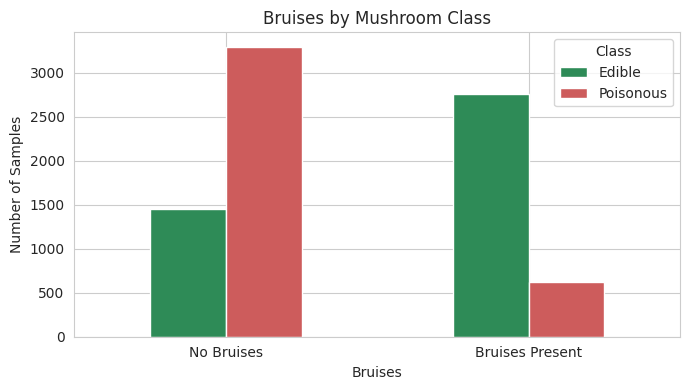

In [ ]:
bruises_table = pd.crosstab(X['bruises'], y)
bruises_table.rename(
    index={'f': 'No Bruises', 't': 'Bruises Present'},
    inplace=True
)
bruises_table.columns = ['Edible', 'Poisonous']

bruises_table.plot(
    kind='bar',
    figsize=(7, 4),
    color=['seagreen', 'indianred']
)

plt.title("Bruises by Mushroom Class")
plt.xlabel("Bruises")
plt.ylabel("Number of Samples")
plt.xticks(rotation=0)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

**Figure 3: Relationship between bruising and mushroom edibility.**

Mushrooms without bruises contain a larger number of poisonous samples, while mushrooms with bruises are mostly edible. The noticeable difference between the two distributions suggests that bruising provides useful information for distinguishing between the target classes.

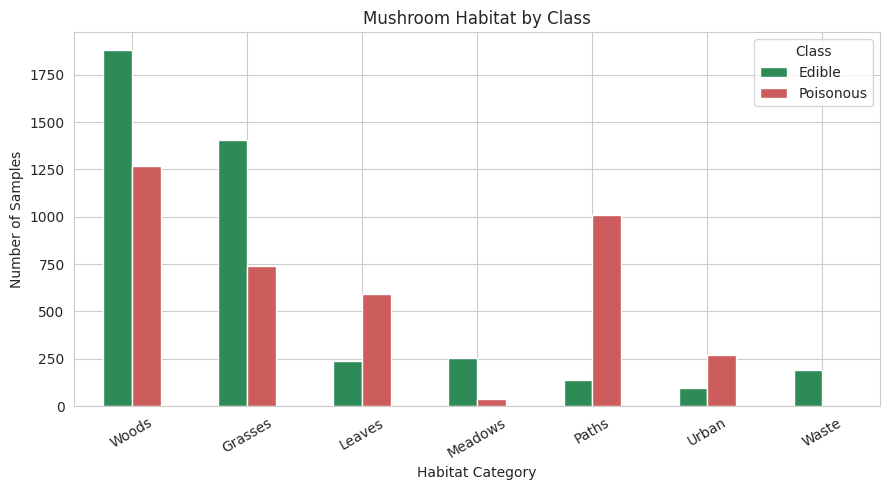

In [ ]:
habitat_table = pd.crosstab(X['habitat'], y)
habitat_table.rename(
    index={
        'd': 'Woods',
        'g': 'Grasses',
        'l': 'Leaves',
        'm': 'Meadows',
        'p': 'Paths',
        'u': 'Urban',
        'w': 'Waste'
    },
    inplace=True
)
habitat_table.columns = ['Edible', 'Poisonous']

habitat_table.plot(
    kind='bar',
    figsize=(9, 5),
    color=['seagreen', 'indianred']
)

plt.title("Mushroom Habitat by Class")
plt.xlabel("Habitat Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=30)
plt.legend(title="Class")
plt.tight_layout()
plt.show()

**Figure 4: Distribution of mushroom classes across different habitats.**

Woods and grasses contain large numbers of both classes but include more edible mushrooms. In contrast, mushrooms found near paths, leaves, and urban environments are more frequently poisonous. Habitat therefore provides useful contextual information, although it cannot determine edibility independently.


# Baseline Classification Model

Logistic Regression was selected as the baseline classifier because it is a simple, interpretable, and widely used model for binary classification. It provides a suitable reference point for evaluating more advanced classifiers in the final project.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

In [ ]:
baseline_model = LogisticRegression(max_iter=1000)

In [ ]:
cv_scores = cross_val_score(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross-validation scores:", cv_scores)
print("Mean cross-validation accuracy:", cv_scores.mean())

Cross-validation scores: [0.99769231 0.99846154 0.99384615 0.99153846 0.99307159]
Mean cross-validation accuracy: 0.9949220110143898


Five-fold cross-validation was performed using only the training data. This provides a more reliable estimate of baseline performance than relying on a single training-validation split.

In [ ]:
baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [ ]:
y_pred = baseline_model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, pos_label='p')

print("Test Accuracy:", accuracy)
print("Poisonous-class F1-score:", f1)

Test Accuracy: 0.9956923076923077
Poisonous-class F1-score: 0.9955099422706863


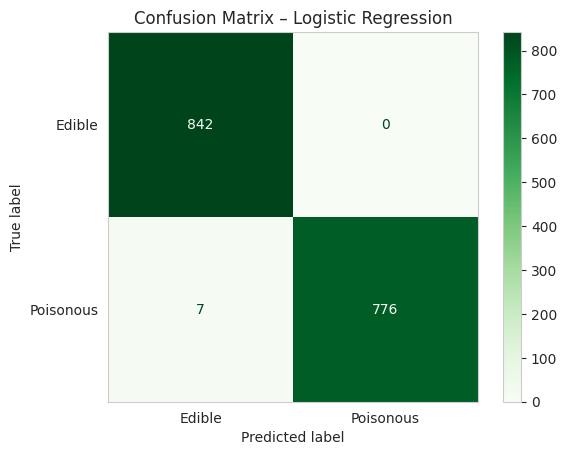

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=['e', 'p']
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Edible', 'Poisonous']
)

display.plot(cmap='Greens')
plt.title("Confusion Matrix – Logistic Regression")
plt.grid(False)
plt.show()

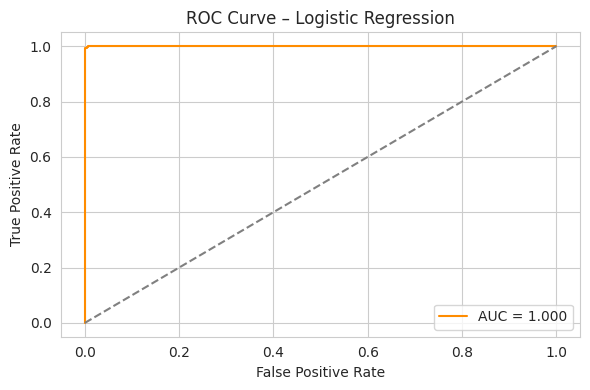

ROC-AUC Score: 0.9999635969821898


In [ ]:
poisonous_index = list(baseline_model.classes_).index('p')
y_probability = baseline_model.predict_proba(X_test)[:, poisonous_index]

y_test_binary = (y_test == 'p').astype(int)

auc_score = roc_auc_score(y_test_binary, y_probability)
fpr, tpr, thresholds = roc_curve(y_test_binary, y_probability)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', label=f'AUC = {auc_score:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')

plt.title("ROC Curve – Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

print("ROC-AUC Score:", auc_score)